<h1 style="text-align: center; font-weight: bold;">DATA EXPLORATION</h1>

This script is for visualization purposes only. For more detailed analysis, please refer to the Data Exploration section in the Report pdf.

## Overview

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

In [2]:
# Read original dataset
data = pd.read_csv('../data/train.csv')

# Display first few rows of dataset
data.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [3]:
# Check size of the dataset
data.shape

(140700, 20)

In [4]:
# Check data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

## `Name`

In [5]:
# Number of distinc names
print(f"Number of distinct names: {data['Name'].nunique()}")

# Number of distinct name with more than one occurrence
name_counts = data['Name'].value_counts()
distinct_names_multiple = (name_counts > 1).sum()
print(f"Number of distinct names with more than one occurrence: {distinct_names_multiple}")

# Number of distinct names with more than 10 occurrences
distinct_names_ten_plus = (name_counts > 10).sum()
print(f"Number of distinct names with more than 10 occurrences: {distinct_names_ten_plus}")

Number of distinct names: 422
Number of distinct names with more than one occurrence: 244
Number of distinct names with more than 10 occurrences: 217


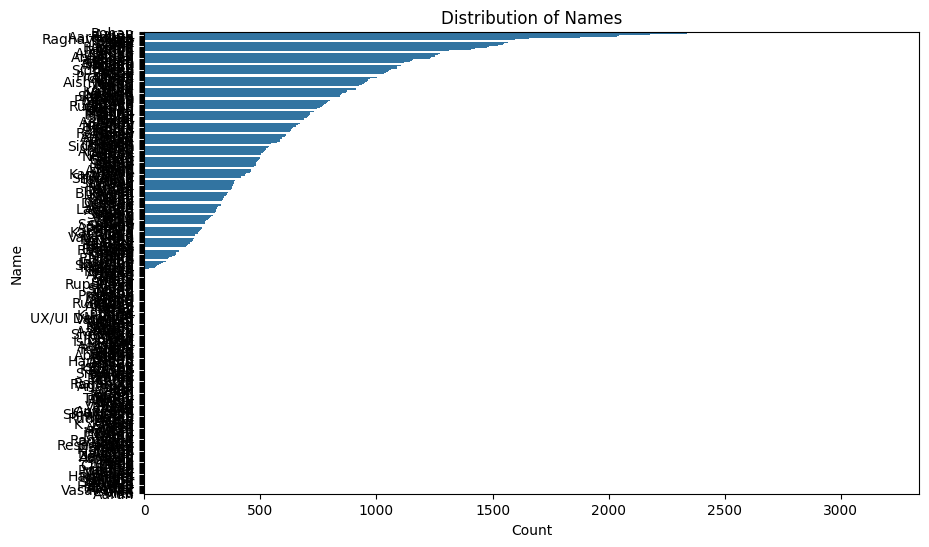

In [6]:
# Bar chart of Name
plt.figure(figsize=(10,6))
sns.countplot(y='Name', data=data, order=data['Name'].value_counts().index)
plt.title('Distribution of Names')
plt.xlabel('Count')
plt.ylabel('Name')
plt.show()

## `Gender`

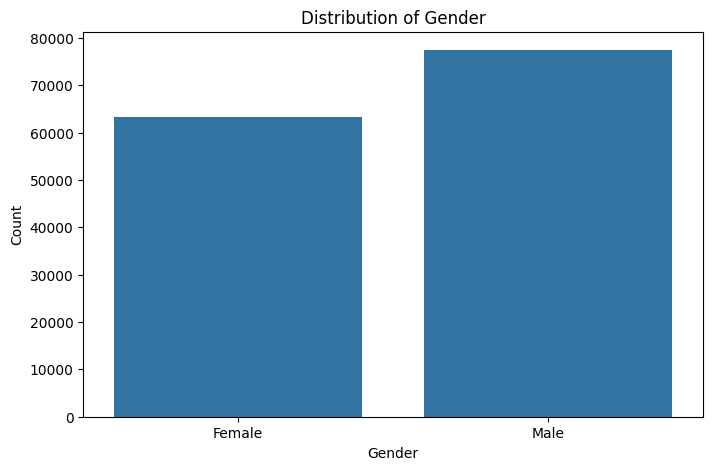

In [7]:
# Bar chart of Gender
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', data=data)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## `Age`

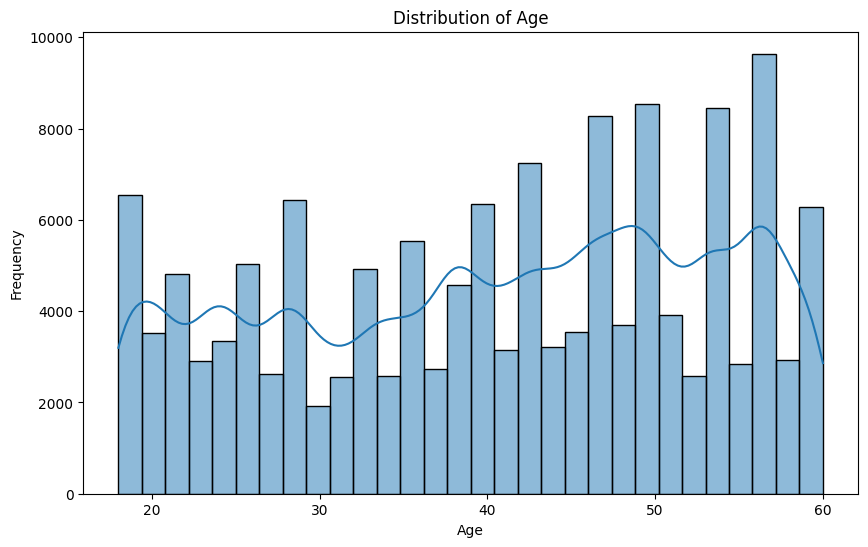

In [8]:
# Histogram of Age
plt.figure(figsize=(10,6))
sns.histplot(data['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## `City`

In [9]:
# Number of distinct cities
print(f"Number of distinct cities: {data['City'].nunique()}")

# Number of distinct cities with more than one occurrence
city_counts = data['City'].value_counts()
print(f"Number of distinct cities with more than one occurrence: {(city_counts > 1).sum()}")

# Number of distinct cities with more than 10 occurrences
print(f"Number of distinct cities with more than 10 occurrences: {(city_counts > 10).sum()}")

Number of distinct cities: 98
Number of distinct cities with more than one occurrence: 46
Number of distinct cities with more than 10 occurrences: 30


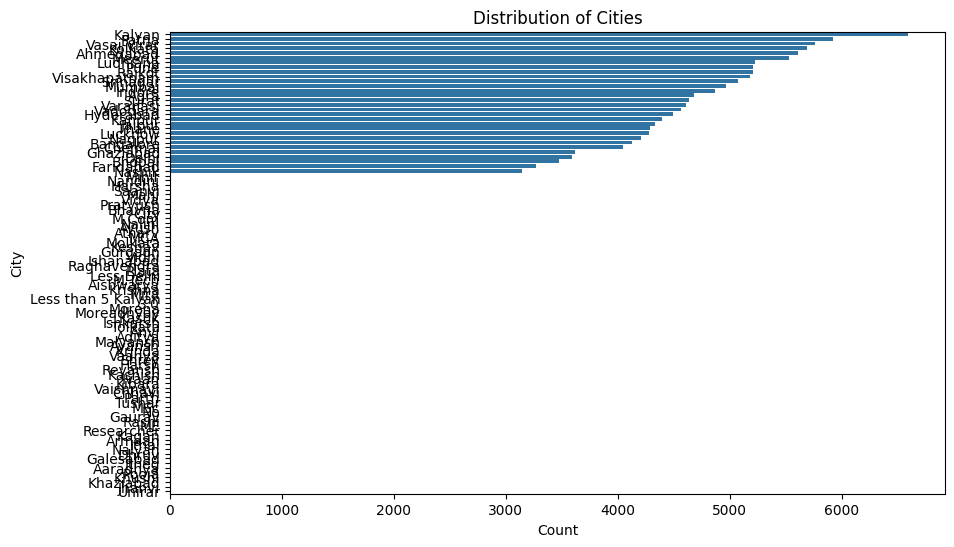

In [10]:
# Bar chart of City
plt.figure(figsize=(10,6))
sns.countplot(y='City', data=data, order=data['City'].value_counts().index)
plt.title('Distribution of Cities')
plt.xlabel('Count')
plt.ylabel('City')
plt.show()

## `Working Professional or Student`

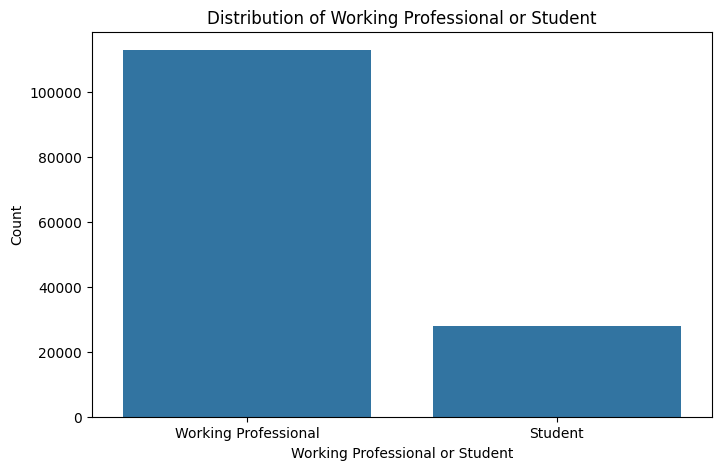

In [11]:
# Distribution of Working Professional or Student
plt.figure(figsize=(8,5))
sns.countplot(x='Working Professional or Student', data=data)
plt.title('Distribution of Working Professional or Student')
plt.xlabel('Working Professional or Student')
plt.ylabel('Count')
plt.show()

## `Profession`

In [12]:
# Number of distinct professions
print(f"Number of distinct professions: {data['Profession'].nunique()}")

# Number of distinct professions with more than one occurrence
profession_counts = data['Profession'].value_counts()
distinct_professions_multiple = (profession_counts > 1).sum()
print(f"Number of distinct professions with more than one occurrence: {distinct_professions_multiple}")

# Number of distinct professions with more than 10 occurrences
distinct_professions_ten_plus = (profession_counts > 10).sum()
print(f"Number of distinct professions with more than 10 occurrences: {distinct_professions_ten_plus}")

Number of distinct professions: 64
Number of distinct professions with more than one occurrence: 44
Number of distinct professions with more than 10 occurrences: 35


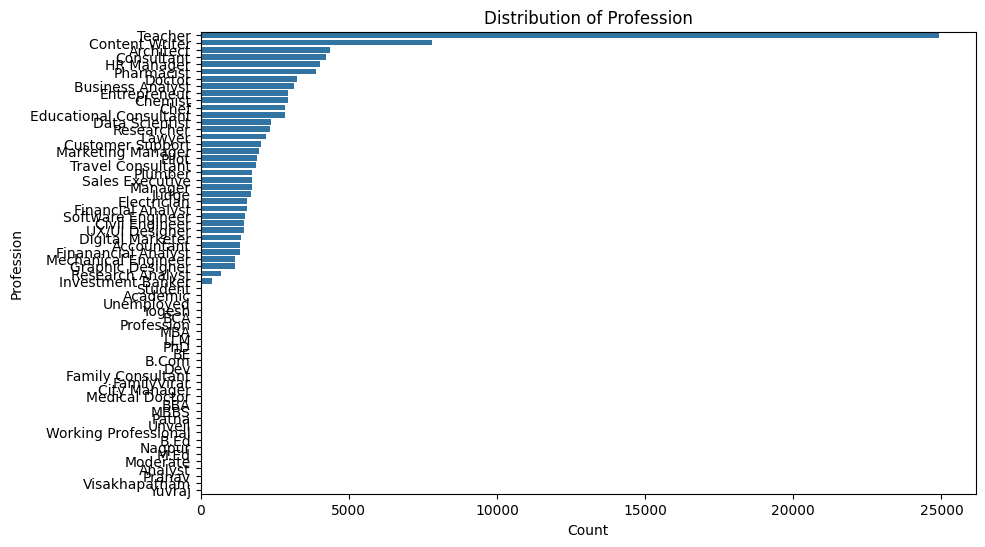

In [13]:
# Bar chart of Profession
plt.figure(figsize=(10,6))
sns.countplot(y='Profession', data=data, order=data['Profession'].value_counts().index)
plt.title('Distribution of Profession')
plt.xlabel('Count')
plt.ylabel('Profession')
plt.show()

## `Academic Pressure` & `Work Pressure`

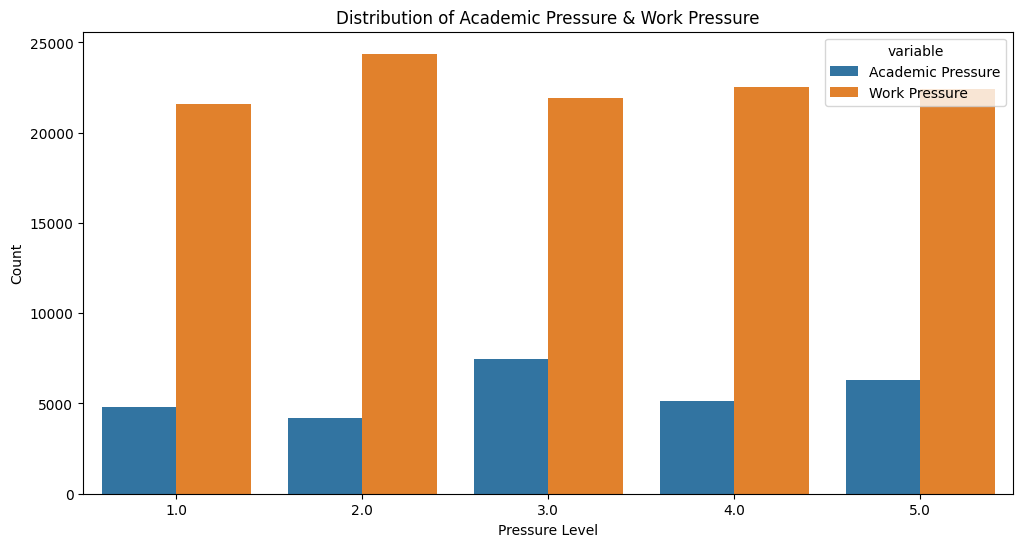

In [14]:
# Bar chart of Academic Pressure & Work Pressure
plt.figure(figsize=(12,6))
sns.countplot(data=data.melt(value_vars=['Academic Pressure', 'Work Pressure']), x='value', hue='variable')
plt.title('Distribution of Academic Pressure & Work Pressure')
plt.xlabel('Pressure Level')
plt.ylabel('Count')
plt.show()

## `CGPA`

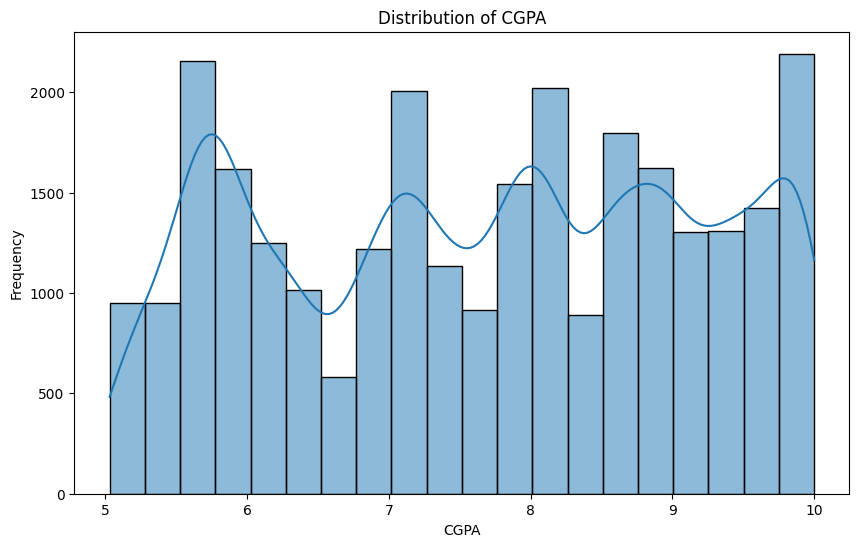

In [15]:
# Histogram of CGPA
plt.figure(figsize=(10,6))
sns.histplot(data['CGPA'], bins=20, kde=True)
plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Frequency')
plt.show()

## `Study Satisfaction` & `Job Satisfaction`

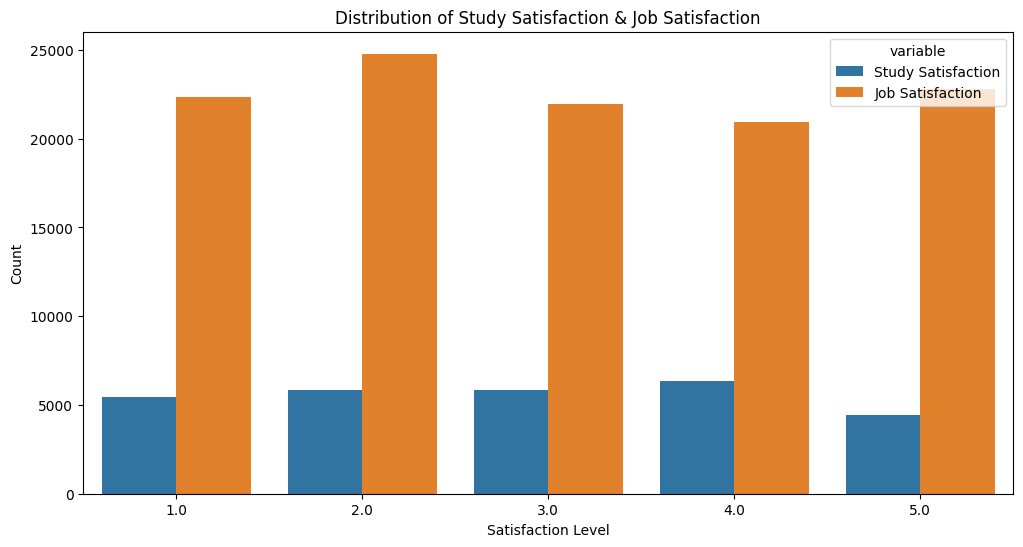

In [16]:
# Bar chart of Study Satisfaction & Job Satisfaction
plt.figure(figsize=(12,6))
sns.countplot(data=data.melt(value_vars=['Study Satisfaction', 'Job Satisfaction']), x='value', hue='variable')
plt.title('Distribution of Study Satisfaction & Job Satisfaction')
plt.xlabel('Satisfaction Level')
plt.ylabel('Count')
plt.show()

## `Sleep Duration`

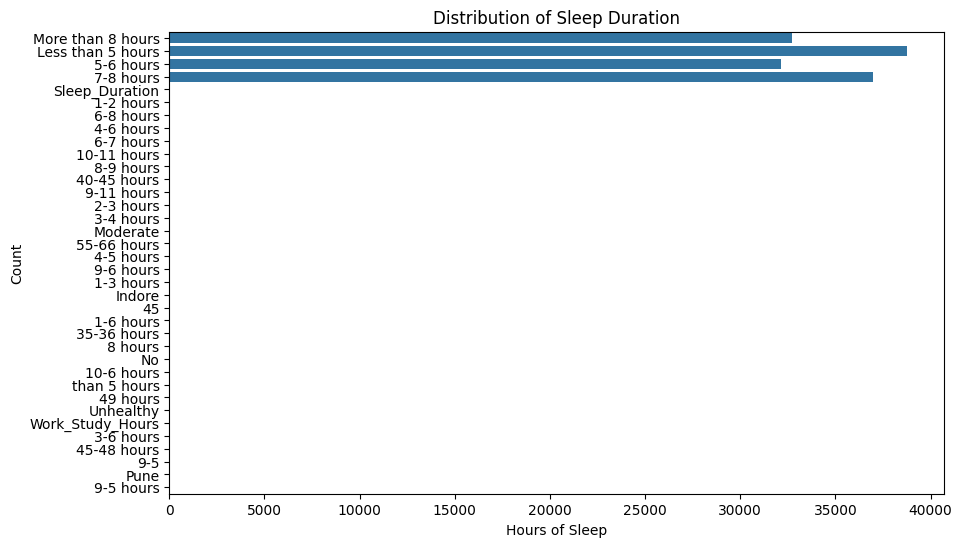

In [17]:
# Bar chart of Sleep Duration
plt.figure(figsize=(10,6))
sns.countplot(data['Sleep Duration'])
plt.title('Distribution of Sleep Duration')
plt.xlabel('Hours of Sleep')
plt.ylabel('Count')
plt.show()

## `Dietary Habits`

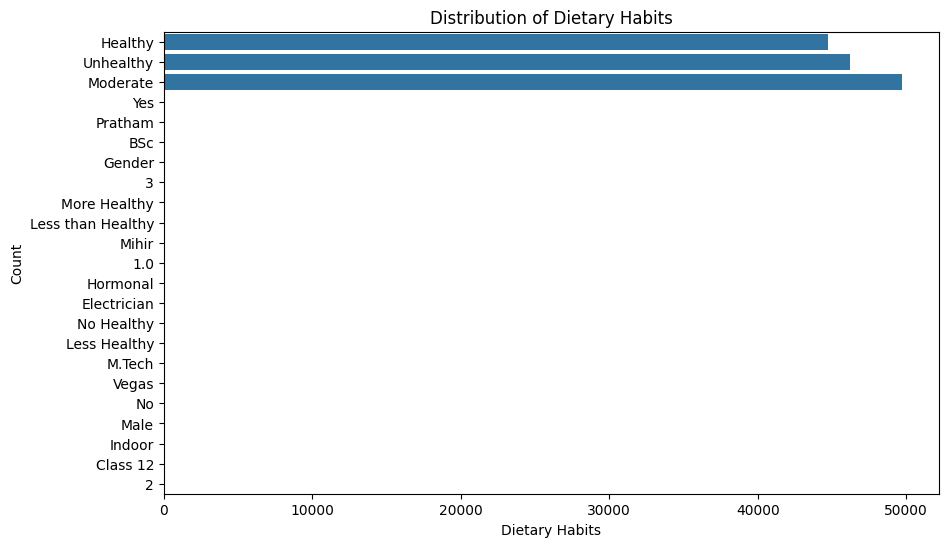

In [18]:
# Bar chart of Dietary Habits
plt.figure(figsize=(10,6))
sns.countplot(data['Dietary Habits'])
plt.title('Distribution of Dietary Habits')
plt.xlabel('Dietary Habits')
plt.ylabel('Count')
plt.show()

## `Degree`

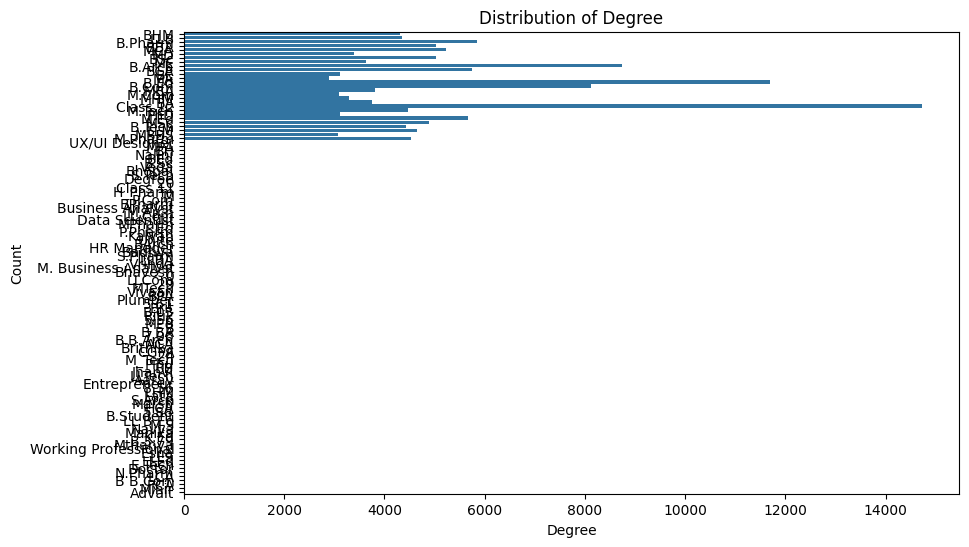

In [19]:
# Bar char of Degree
plt.figure(figsize=(10,6))
sns.countplot(data['Degree'])
plt.title('Distribution of Degree')
plt.xlabel('Degree')
plt.ylabel('Count')
plt.show()

## `Have you ever had suicidal thoughts ?`

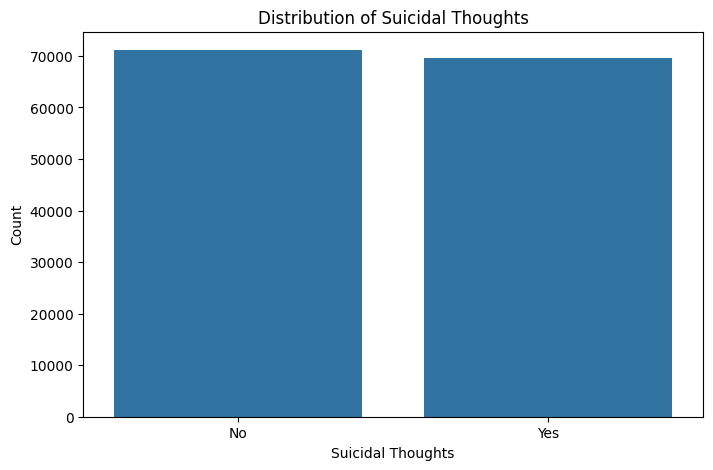

In [20]:
# Bar chart of Have you ever had suicidal thoughts ?
plt.figure(figsize=(8,5))
sns.countplot(x = 'Have you ever had suicidal thoughts ?', data=data)
plt.title('Distribution of Suicidal Thoughts')
plt.xlabel('Suicidal Thoughts')
plt.ylabel('Count')
plt.show()

## `Work/Study Hours`

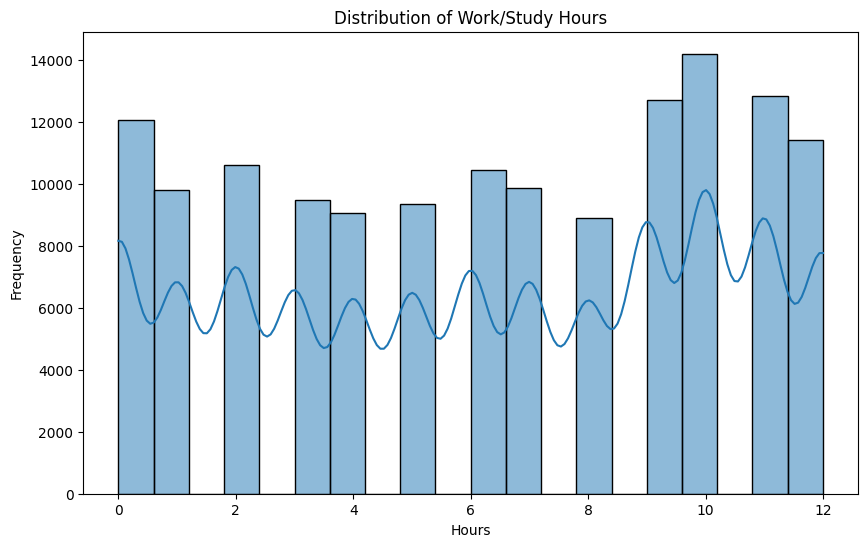

In [21]:
# Histogram of Work/Study Hours
plt.figure(figsize=(10,6))
sns.histplot(data['Work/Study Hours'], bins=20, kde=True)
plt.title('Distribution of Work/Study Hours')
plt.xlabel('Hours')
plt.ylabel('Frequency')
plt.show()

## `Financial Stress`

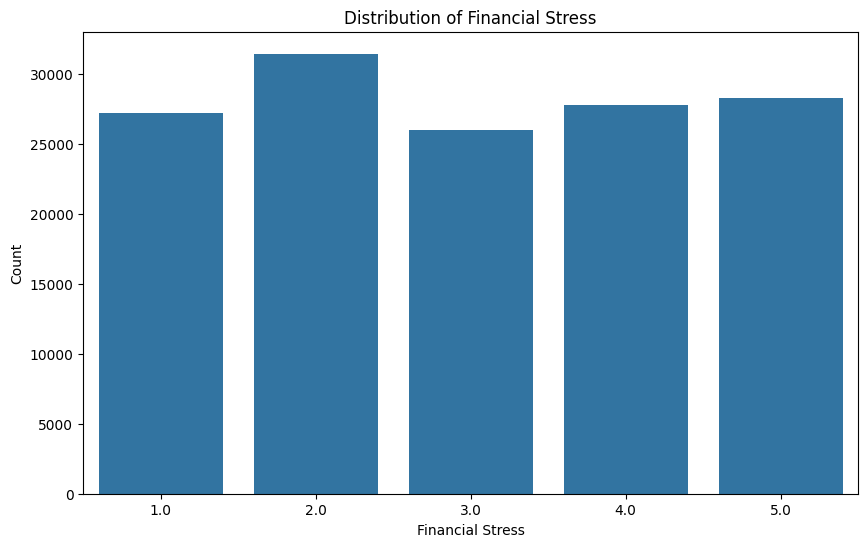

In [22]:
# Bar chart of Financial Stress
plt.figure(figsize=(10,6))
sns.countplot(x='Financial Stress', data=data)
plt.title('Distribution of Financial Stress')
plt.xlabel('Financial Stress')
plt.ylabel('Count')
plt.show()

## `Family History of Mental Illness`

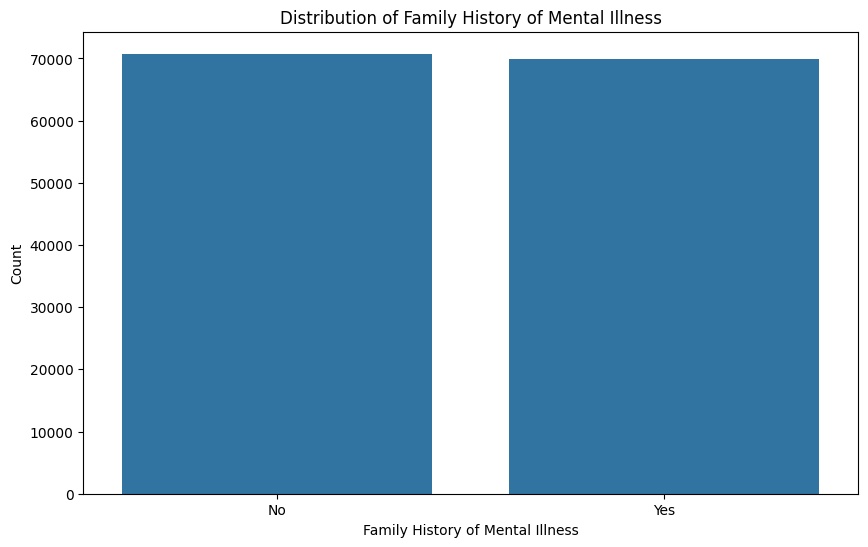

In [23]:
# Bar chart of Family History of Mental Illness
plt.figure(figsize=(10,6))
sns.countplot(x='Family History of Mental Illness', data=data)
plt.title('Distribution of Family History of Mental Illness')
plt.xlabel('Family History of Mental Illness')
plt.ylabel('Count')
plt.show()

## `Depression`

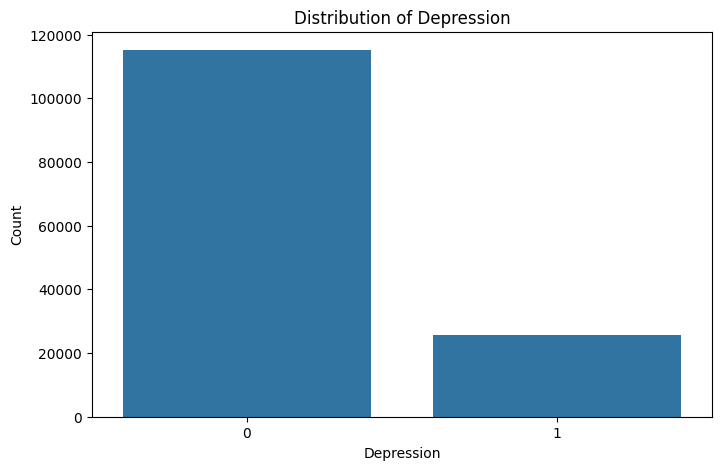

In [24]:
# Bar chart of Depression
plt.figure(figsize=(8,5))
sns.countplot(x='Depression', data=data)
plt.title('Distribution of Depression')
plt.xlabel('Depression')
plt.ylabel('Count')
plt.show()

## Visualization using TSNE

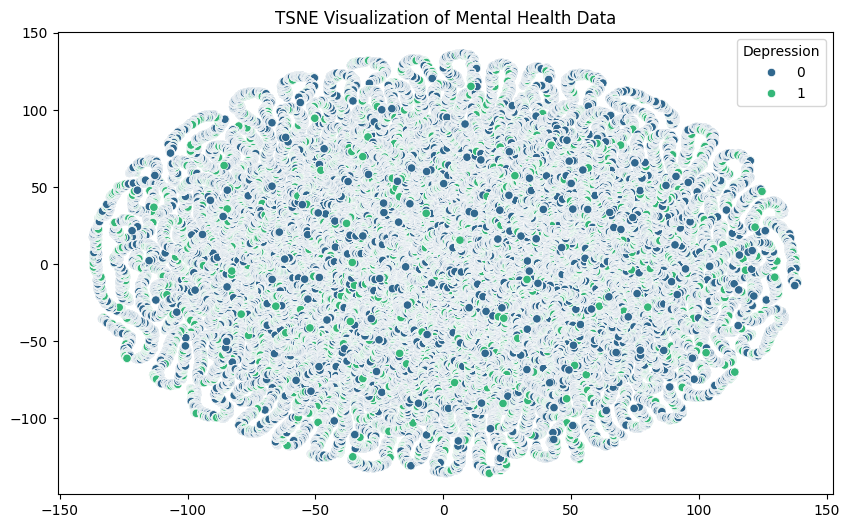

In [26]:
# Extract labels
labels = data['Depression']

# Visualization using TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=10, max_iter=1000)
tsne_results = tsne.fit_transform(data.select_dtypes(include=[np.number]).fillna(0))

plt.figure(figsize=(10,6))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=labels, palette='viridis')
plt.title('TSNE Visualization of Mental Health Data')
plt.show()